# 📐 Teoría de la Regularización en Machine Learning

## 1. El Problema del Sobreajuste (Overfitting)

Cuando entrenamos modelos complejos, corremos el riesgo de que aprendan el ruido en los datos de entrenamiento en lugar de la señal subyacente. Esto es especialmente común en regresiones polinomiales de alto grado.

La ecuación de un modelo polinomial es:
$$y = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_n x^n$$

Los modelos sobreajustados tienden a tener coeficientes $\theta_i$ con valores muy grandes, lo que hace que la función sea demasiado "ondulante" y se ajuste perfectamente a los datos de entrenamiento, pero falle al generalizar con nuevos datos.

### 1.1 Visualizando el Sobreajuste

A continuación, generamos datos sintéticos y ajustamos un polinomio de alto grado para observar el sobreajuste.

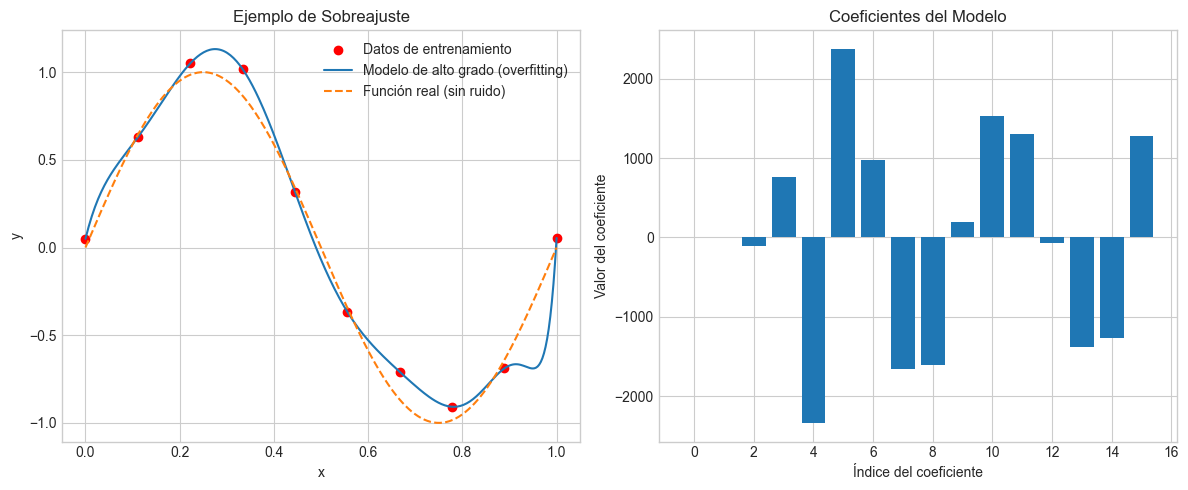

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Configuración para gráficos
plt.style.use('seaborn-v0_8-whitegrid')

# Generamos datos sintéticos
np.random.seed(42)
X = np.linspace(0, 1, 10).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + 0.1 * np.random.randn(10)

# Ajustamos un polinomio de grado 15 (modelo complejo)
polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('linear', LinearRegression())
])
polynomial_model.fit(X, y)

# Generamos puntos para la curva de predicción
X_test = np.linspace(0, 1, 300).reshape(-1, 1)
y_pred = polynomial_model.predict(X_test)

# Graficamos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='red', label='Datos de entrenamiento')
plt.plot(X_test, y_pred, label='Modelo de alto grado (overfitting)')
plt.plot(X_test, np.sin(2 * np.pi * X_test), '--', label='Función real (sin ruido)')
plt.legend()
plt.title('Ejemplo de Sobreajuste')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1, 2, 2)
plt.bar(range(len(polynomial_model.named_steps['linear'].coef_)), 
        polynomial_model.named_steps['linear'].coef_)
plt.title('Coeficientes del Modelo')
plt.xlabel('Índice del coeficiente')
plt.ylabel('Valor del coeficiente')
plt.tight_layout()
plt.show()

## 2. La Regularización como Solución

La regularización introduce una penalización en la función de costo para mantener los coeficientes pequeños. La función de costo general para un modelo lineal regularizado es:

$$J(\theta) = \text{MSE}(\theta) + \alpha \cdot R(\theta)$$

Donde:
*   $\text{MSE}(\theta)$ es el error cuadrático medio.
*   $\alpha$ es el parámetro de regularización que controla la fuerza de la penalización.
*   $R(\theta)$ es el término de regularización.

### 2.1 Regularización Ridge (L2)

La regularización Ridge añade la suma de los cuadrados de los coeficientes:

$$R(\theta) = \sum_{i=1}^{n} \theta_i^2$$

La función de costo se convierte en:

$$J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2$$

### 2.2 Regularización Lasso (L1)

La regularización Lasso añade la suma de los valores absolutos de los coeficientes:

$$R(\theta) = \sum_{i=1}^{n} |\theta_i|$$

La función de costo se convierte en:

$$J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|$$

### 2.3 Elastic Net

Elastic Net combina ambas regularizaciones:

$$J(\theta) = \text{MSE}(\theta) + \alpha \left( \rho \sum_{i=1}^{n} |\theta_i| + \frac{1-\rho}{2} \sum_{i=1}^{n} \theta_i^2 \right)$$

Donde $\rho$ controla la mezcla entre L1 y L2.

## 3. Implementación "From Scratch" de la Regularización

Para entender mejor cómo funciona, implementaremos el descenso por gradiente con regularización Ridge.

In [10]:
class RidgeRegressionScratch:
    """Implementación de Regresión Ridge usando Descenso por Gradiente."""
    def __init__(self, alpha=1.0, learning_rate=0.01, n_iterations=1000):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.loss_history = []

    def fit(self, X, y):
        # Añadimos el término de sesgo (columna de unos)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        m = len(X_b)
        self.theta = np.random.randn(X_b.shape[1], 1)
        y = y.reshape(-1, 1)

        for iteration in range(self.n_iterations):
            # Calculamos los gradientes
            gradients = 2/m * X_b.T.dot(X_b.dot(self.theta) - y)
            # Añadimos el gradiente del término de regularización (excepto para theta_0)
            gradients[1:] += 2 * self.alpha * self.theta[1:]

            # Actualizamos los parámetros
            self.theta -= self.learning_rate * gradients

            # Guardamos el error para visualización
            loss = np.mean((X_b.dot(self.theta) - y)**2) + self.alpha * np.sum(self.theta[1:]**2)
            self.loss_history.append(loss)

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta)

### 3.1 Probando Nuestra Implementación

Usaremos los mismos datos sintéticos para comparar un modelo lineal simple con nuestro modelo Ridge.

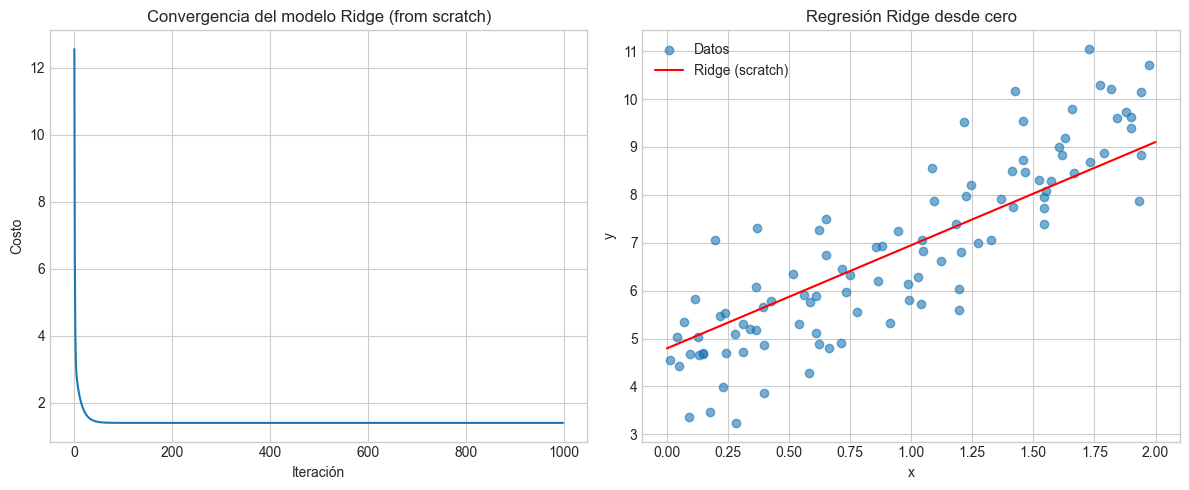

In [11]:
# Generamos datos con una relación lineal más simple para esta demostración
np.random.seed(42)
X_simple = 2 * np.random.rand(100, 1)
y_simple = 4 + 3 * X_simple + np.random.randn(100, 1)

# Entrenamos nuestro modelo Ridge
ridge_scratch = RidgeRegressionScratch(alpha=0.1, learning_rate=0.1, n_iterations=1000)
ridge_scratch.fit(X_simple, y_simple)

# Graficamos la convergencia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ridge_scratch.loss_history)
plt.title('Convergencia del modelo Ridge (from scratch)')
plt.xlabel('Iteración')
plt.ylabel('Costo')

plt.subplot(1, 2, 2)
X_test_simple = np.linspace(0, 2, 100).reshape(-1, 1)
y_pred_scratch = ridge_scratch.predict(X_test_simple)
plt.scatter(X_simple, y_simple, alpha=0.6, label='Datos')
plt.plot(X_test_simple, y_pred_scratch, 'r-', label='Ridge (scratch)')
plt.title('Regresión Ridge desde cero')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Implementación con Scikit-Learn

Ahora, comparemos nuestra implementación con las eficientes y optimizadas versiones de `scikit-learn`.

Coeficientes del modelo from scratch: [4.79337372 2.15516098]
Coeficientes del modelo scikit-learn:   [4.222507838591144, 2.7622316503733857]


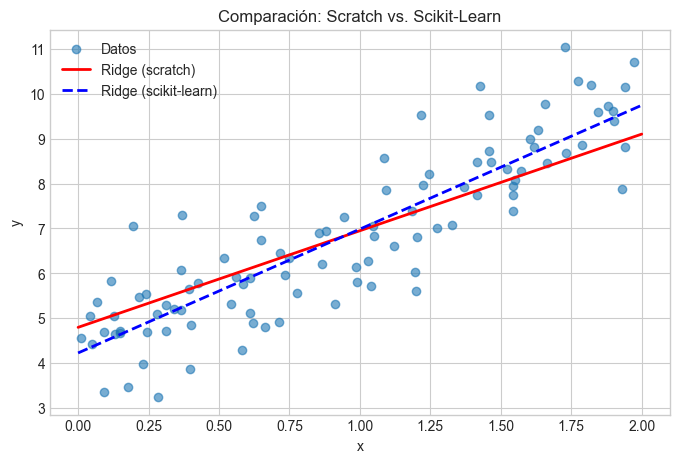

In [12]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# Modelo Ridge de scikit-learn
ridge_sklearn = Ridge(alpha=0.1)
ridge_sklearn.fit(X_simple, y_simple)
y_pred_sklearn = ridge_sklearn.predict(X_test_simple)

# Comparación de coeficientes
print("Coeficientes del modelo from scratch:", ridge_scratch.theta.ravel())
print("Coeficientes del modelo scikit-learn:  ", [ridge_sklearn.intercept_[0]] + list(ridge_sklearn.coef_))

# Visualización de la diferencia
plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y_simple, alpha=0.6, label='Datos')
plt.plot(X_test_simple, y_pred_scratch, 'r-', label='Ridge (scratch)', linewidth=2)
plt.plot(X_test_simple, y_pred_sklearn, 'b--', label='Ridge (scikit-learn)', linewidth=2)
plt.title('Comparación: Scratch vs. Scikit-Learn')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 5. Efecto del Parámetro de Regularización α

El parámetro $\alpha$ controla la fuerza de la regularización. Valores muy pequeños ($\alpha \to 0$) se comportan como una regresión lineal normal (propensa al sobreajuste). Valores muy grandes ($\alpha \to \infty$) pueden llevar al subajuste (underfitting).

h:\Anaconda\envs\deepf\lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


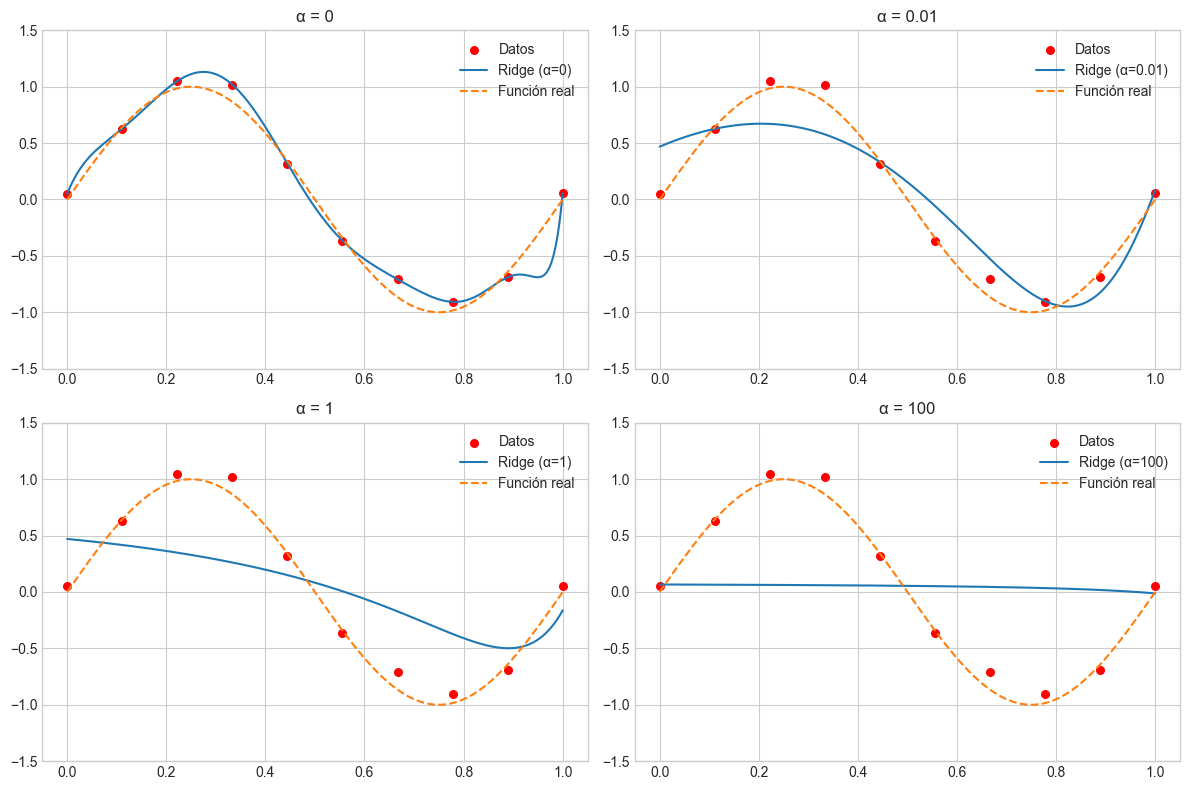

In [13]:
# Usamos los datos polinomiales del principio
alphas = [0, 0.01, 1, 100]
plt.figure(figsize=(12, 8))

for i, alpha in enumerate(alphas):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(X, y)
    y_pred = model.predict(X_test)

    plt.subplot(2, 2, i+1)
    plt.scatter(X, y, color='red', s=30, label='Datos')
    plt.plot(X_test, y_pred, label=f'Ridge (α={alpha})')
    plt.plot(X_test, np.sin(2 * np.pi * X_test), '--', label='Función real')
    plt.ylim(-1.5, 1.5)
    plt.legend()
    plt.title(f'α = {alpha}')

plt.tight_layout()
plt.show()

## 6. Selección del Parámetro α mediante Validación Cruzada

La mejor manera de elegir $\alpha$ es mediante validación cruzada. Scikit-learn proporciona modelos como `RidgeCV` que lo hacen automáticamente.

In [21]:
from sklearn.linear_model import RidgeCV

# Definimos un rango de alphas a probar
alphas_to_try = np.logspace(-3, 3, 100)

# Creamos un pipeline con validación cruzada
ridge_cv = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('ridge_cv', RidgeCV(alphas=alphas_to_try))
])

ridge_cv.fit(X, y)

# Resultados
print(f"Mejor α encontrado: {ridge_cv.named_steps['ridge_cv'].alpha_}")


Mejor α encontrado: 0.0015199110829529332


## 7. Comparación Final: Ridge, Lasso y Elastic Net

Finalmente, comparamos los tres tipos de regularización para ver sus diferencias en los coeficientes resultantes.

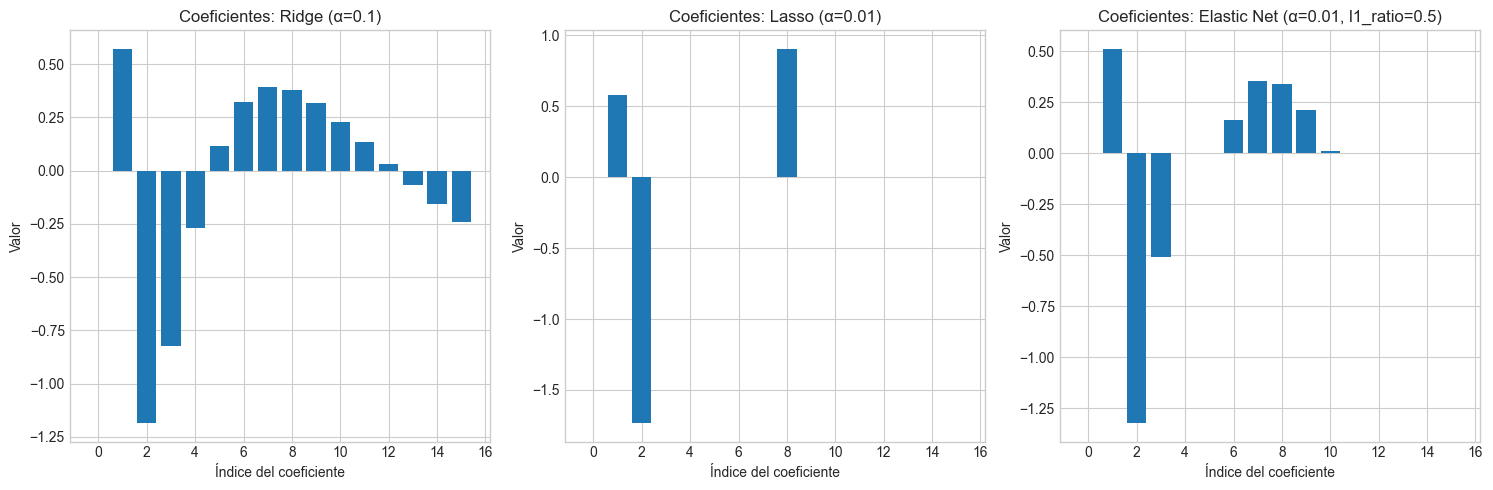

In [23]:
from sklearn.preprocessing import StandardScaler
models = {
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Lasso (α=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'Elastic Net (α=0.01, l1_ratio=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items()):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('scaler', StandardScaler(with_mean=False)),
        ('reg', model)
    ])
    pipe.fit(X, y)

    plt.subplot(1, 3, i+1)
    coefs = pipe.named_steps['reg'].coef_
    plt.bar(range(len(coefs)), coefs)
    plt.title(f'Coeficientes: {name}')
    plt.xlabel('Índice del coeficiente')
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

## Conclusiones

*   **Ridge (L2)** tiende a reducir los coeficientes de manera uniforme, pero rara vez los lleva a cero.
*   **Lasso (L1)** puede llevar coeficientes exactamente a cero, realizando así una selección de características.
*   **Elastic Net** combina ambas propiedades.
*   La elección del parámetro de regularización $\alpha$ es crucial y debe hacerse mediante validación cruzada.